
## Прогнозирование выбора кафедры студентами ИТММ
Крошко Екатерина, 2025


### Первый приоритет

| ГРУППА | кафедра | **выбор** | **Сумма по группе** | **Процент от общего** |
| --- | --- | --- | --- | --- |
| 1 | ДУМЧА | 22 | **59**   | 7.33% |
|  | АГДМ | 37 |  | 12.33% |
| 2 | МОСТ | 121 | **121** | 40.33% |
| 3 | ТУДС | 18 | **120** | 6.00% |
|  | ТВИАД | 22 |  | 7.33% |
|  | ТКЭМ | 9 |  | 3.00% |
|  | ПМ | 22 |  | 7.33% |
|  | ИАНИ | 49 |  | 16.33% |

### Последний приоритет

| ГРУППА | кафедра | **выбор** | **Сумма по группе** | **Процент от общего** |
| --- | --- | --- | --- | --- |
| 1 | ДУМЧА | 64 | **148** | 25.70% |
|  | АГДМ | 84 |  | 33.73% |
| 2 | МОСТ | 11 | **11** | 4.42% |
| 3 | ТУДС | 11 | **90** | 4.42% |
|  | ТВИАД | 13 |  | 5.22% |
|  | ТКЭМ | 32 |  | 12.85% |
|  | ПМ | 34 |  | 13.65% |


In [1]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=bd3c75465bf2774b65ddde9c911dd596431bc3d14b09f252ac69fdff33268c83
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.pipeline import Pipeline


# Загрузка файла
file_name = 'База.xlsx'
df = pd.read_excel(file_name, sheet_name='Лист1', engine='openpyxl')

Корреляционная матрица:
                                 Математика  Русский язык  Информатика   \
Математика                        1.000000      0.503544      0.656057   
Русский язык                      0.503544      1.000000      0.483294   
Информатика                       0.656057      0.483294      1.000000   
Физика                            0.596393      0.533773           NaN   
sr_o                              0.371323      0.353071      0.553315   
индивидуальные_достижения балл    0.298196      0.340883      0.257222   

                                  Физика      sr_o  \
Математика                      0.596393  0.371323   
Русский язык                    0.533773  0.353071   
Информатика                          NaN  0.553315   
Физика                          1.000000  0.365698   
sr_o                            0.365698  1.000000   
индивидуальные_достижения балл  0.235719  0.261001   

                                индивидуальные_достижения балл  
Математика  

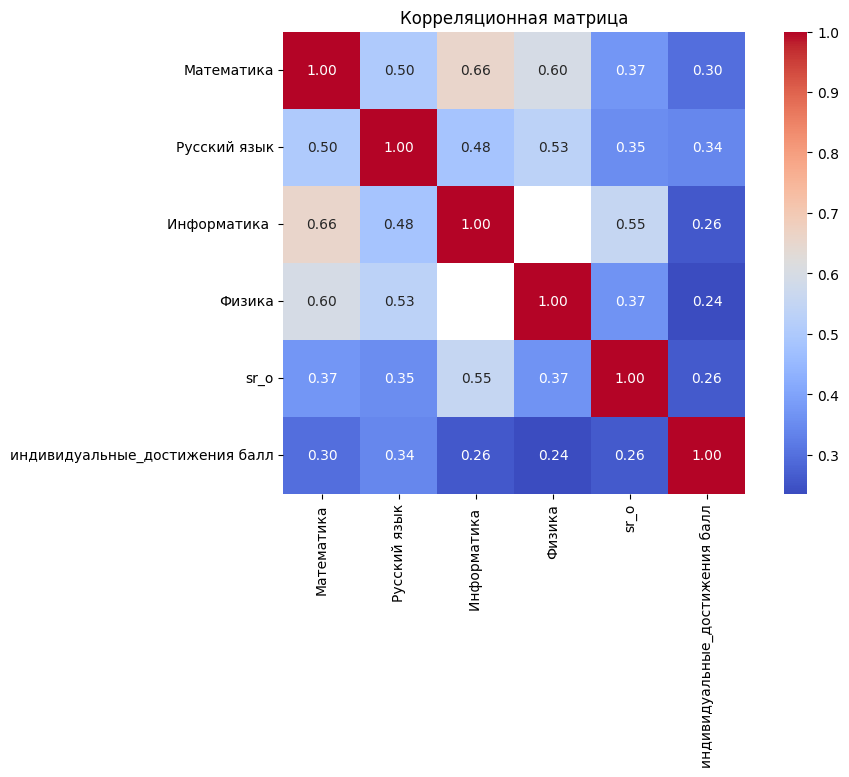

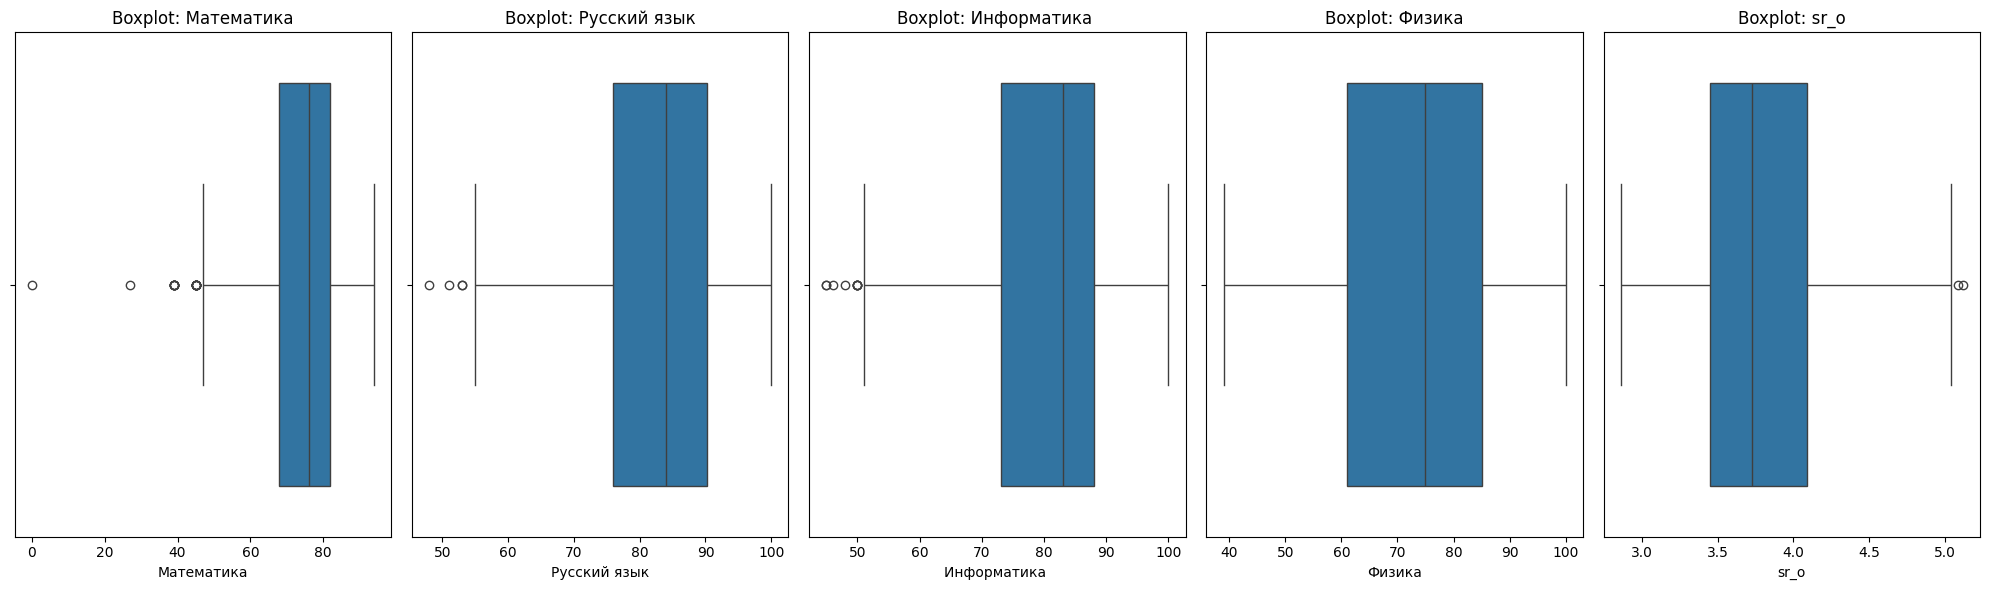

In [4]:
# Маппинг кафедр (один — для обоих приоритетов, кафедры одинаковые)
priority_mapping = {
    'АГДМ': 1, 'ТВиАД': 2, 'ПМ': 3, 'ИАНИ': 4,
    'МОСТ': 5, 'ТУДС': 6, 'ДУМЧА': 7, 'ТКЭМ': 8
}

direction_mapping = {
    '01.03.01 Математика': 1,
    '01.03.02 Прикладная математика и информатика': 2,
    '01.03.03 Механика и математическое моделирование': 3,
    '01.05.01 Фундаментальные математика и механика': 4,
    '02.03.02 Фундаментальная информатика и информационные технологии': 5,
    '09.03.03 Прикладная информатика': 6,
    '09.03.04 Программная инженерия': 7
}

# Корреляционная матрица по числовым признакам
num_cols = ['Математика', 'Русский язык', 'Информатика ', 'Физика',
            'sr_o', 'индивидуальные_достижения балл']
correlation_matrix = df[num_cols].corr()
print("Корреляционная матрица:\n", correlation_matrix)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Корреляционная матрица')
plt.show()

# Распределение баллов
subjects = ['Математика', 'Русский язык', 'Информатика ', 'Физика', 'sr_o']
fig, axes = plt.subplots(1, len(subjects), figsize=(20, 6))
for ax, subject in zip(axes, subjects):
    subject_data = df[subject].dropna()
    if not subject_data.empty:
        sns.boxplot(x=subject_data, ax=ax)
        ax.set_title(f'Boxplot: {subject}')
plt.tight_layout()
plt.show()

## основной код для первого приориета:

/tmp/ipykernel_31970/762854553.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Приоритет_кафедры_высокий'] = df['Приоритет_кафедры_высокий'].replace(priority_mapping)
/tmp/ipykernel_31970/762854553.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['направление_подготовки'] = df['направление_подготовки'].replace(direction_mapping)



Логистическая регрессия:
              precision    recall  f1-score   support

           1       0.32      0.73      0.44        11
           2       0.52      0.58      0.55        24
           3       0.76      0.45      0.57        42

    accuracy                           0.53        77
   macro avg       0.53      0.59      0.52        77
weighted avg       0.62      0.53      0.54        77



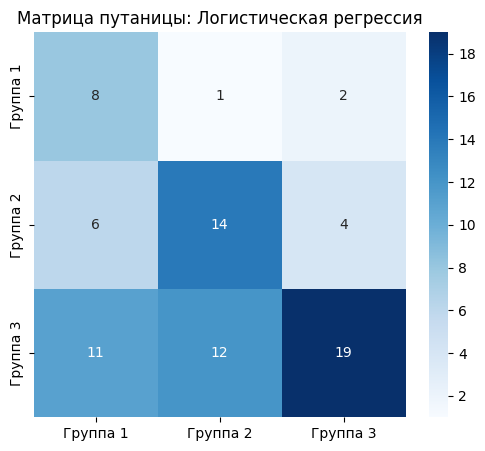


Дерево решений:
              precision    recall  f1-score   support

           1       0.38      0.45      0.42        11
           2       0.63      0.50      0.56        24
           3       0.80      0.86      0.83        42

    accuracy                           0.69        77
   macro avg       0.61      0.60      0.60        77
weighted avg       0.69      0.69      0.68        77



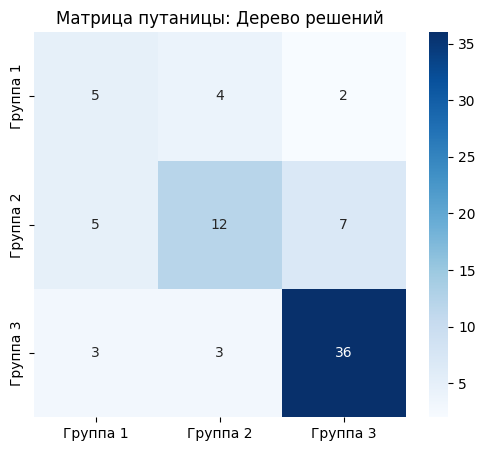


Случайный лес:
              precision    recall  f1-score   support

           1       0.50      0.45      0.48        11
           2       0.88      0.58      0.70        24
           3       0.75      0.90      0.82        42

    accuracy                           0.74        77
   macro avg       0.71      0.65      0.66        77
weighted avg       0.75      0.74      0.73        77



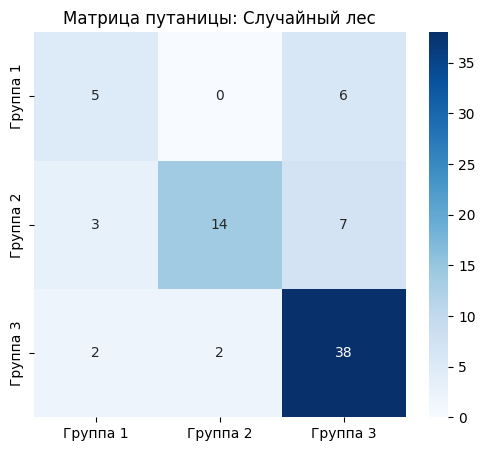


Градиентный бустинг:
              precision    recall  f1-score   support

           1       0.54      0.64      0.58        11
           2       0.75      0.62      0.68        24
           3       0.80      0.83      0.81        42

    accuracy                           0.74        77
   macro avg       0.69      0.70      0.69        77
weighted avg       0.74      0.74      0.74        77



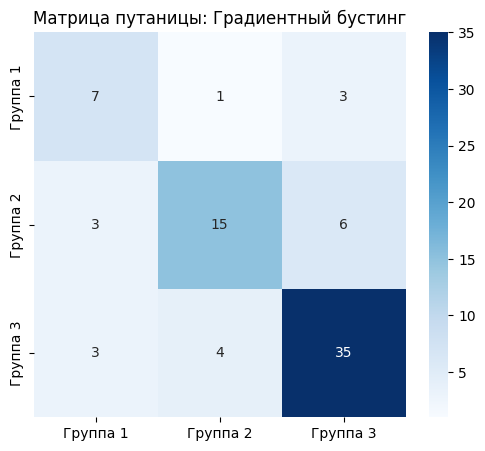


Сбалансированный случайный лес:
              precision    recall  f1-score   support

           1       0.30      0.64      0.41        11
           2       0.70      0.67      0.68        24
           3       0.87      0.64      0.74        42

    accuracy                           0.65        77
   macro avg       0.62      0.65      0.61        77
weighted avg       0.74      0.65      0.67        77



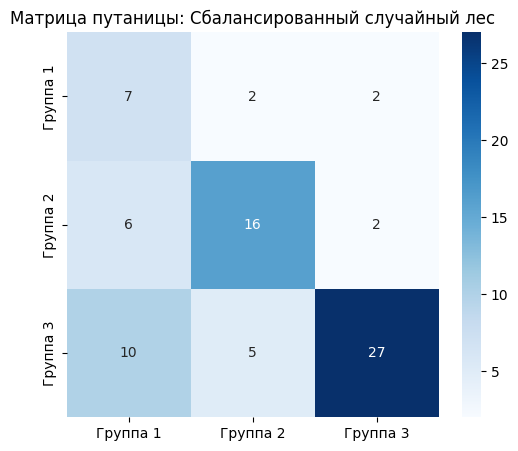


Бэггинг-классификатор:
              precision    recall  f1-score   support

           1       0.46      0.55      0.50        11
           2       0.76      0.67      0.71        24
           3       0.79      0.81      0.80        42

    accuracy                           0.73        77
   macro avg       0.67      0.67      0.67        77
weighted avg       0.73      0.73      0.73        77



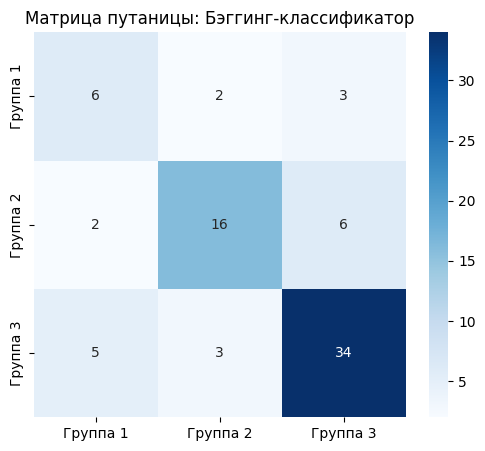


Кросс-валидация (F1 macro) — первый приоритет:
  Логистическая регрессия: 0.493 +/- 0.019
  Дерево решений: 0.595 +/- 0.040
  Случайный лес: 0.561 +/- 0.059
  Градиентный бустинг: 0.646 +/- 0.037
  Сбалансированный случайный лес: 0.598 +/- 0.067
  Бэггинг-классификатор: 0.615 +/- 0.027


In [5]:
df = pd.read_excel(file_name, sheet_name='Лист1', engine='openpyxl')

df['Приоритет_кафедры_высокий'] = df['Приоритет_кафедры_высокий'].replace(priority_mapping)
df['Группа'] = np.where(df['Приоритет_кафедры_высокий'].isin([1, 7]), 1,
                        np.where(df['Приоритет_кафедры_высокий'].isin([5]), 2, 3))

df['Информатика '] = df['Информатика '].fillna(0)
df['Физика'] = df['Физика'].fillna(0)
df = df.dropna(subset=['Математика', 'sr_o', 'Русский язык',
                       'индивидуальные_достижения балл', 'статус'])
df['направление_подготовки'] = df['направление_подготовки'].replace(direction_mapping)

X_high = df[['Русский язык', 'Математика', 'Информатика ', 'Физика', 'sr_o',
             'индивидуальные_достижения балл', 'направление_подготовки']]
y_high = df['Группа']

X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(
    X_high, y_high, test_size=0.2, random_state=42, stratify=y_high
)

scaler_high = StandardScaler()
X_train_high_sc = scaler_high.fit_transform(X_train_high)
X_test_high_sc  = scaler_high.transform(X_test_high)

models = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Дерево решений': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Случайный лес': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Градиентный бустинг': GradientBoostingClassifier(random_state=42),
    'Сбалансированный случайный лес': BalancedRandomForestClassifier(random_state=42),
    'Бэггинг-классификатор': BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)
}

for name, model in models.items():
    model.fit(X_train_high_sc, y_train_high)
    y_pred = model.predict(X_test_high_sc)
    print(f"\n{name}:")
    print(classification_report(y_test_high, y_pred, zero_division=0))

    cm = confusion_matrix(y_test_high, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Группа 1', 'Группа 2', 'Группа 3'],
                yticklabels=['Группа 1', 'Группа 2', 'Группа 3'])
    plt.title(f'Матрица путаницы: {name}')
    plt.show()

# Кросс-валидация для всех моделей
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\nКросс-валидация (F1 macro) — первый приоритет:")
for name, model in models.items():
    pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    scores = cross_val_score(pipeline, X_high, y_high, cv=cv, scoring='f1_macro')
    print(f"  {name}: {scores.mean():.3f} +/- {scores.std():.3f}")


# Сравнение моделей, первый приоритет:

**Логистическая регрессия:м**

Показала наихудшие результаты с точностью 53% и macro F1 0.52. Группа 1 предсказывается с высоким recall (0.73), но очень низким precision (0.32), модель часто ошибочно относит объекты к этой группе.

Группа 3 имеет высокий precision (0.76), но низкий recall (0.45). Кросс-валидация: F1 macro = 0.493 ± 0.019.


**Дерево решений:**

Умеренные результаты: точность 69%, macro F1 0.60. Хорошо справляется с группой 3 (recall 0.86), слабее с группой 1 (recall 0.45) и группой 2 (recall 0.50).

Кросс-валидация: F1 macro = 0.595 ± 0.040.


**Случайный лес:**

Точность 74%, macro F1 0.66. Лучший recall для группы 3 (0.90). Группа 2 предсказывается с высоким precision (0.88), но умеренным recall (0.58). Группа 1 предсказывается слабо (recall 0.45).

Кросс-валидация: F1 macro = 0.561 ± 0.059.


**Градиентный бустинг:**

Точность 74%, macro F1 0.69 лучший показатель среди всех моделей.

Наиболее сбалансированные результаты по всем группам:

группа 1 (recall 0.64), группа 2 (recall 0.62), группа 3 (recall 0.83).

Кросс-валидация подтверждает устойчивость:

F1 macro = 0.646 ± 0.037 — лучший результат по всем моделям.



**Сбалансированный случайный лес:**

Точность 65%, macro F1 0.61. Несмотря на балансировку классов, accuracy ниже обычного случайного леса.

Группа 2 предсказывается лучше (recall 0.67), но группа 3 заметно хуже (recall 0.64).

Кросс-валидация: F1 macro = 0.598 ± 0.067.



**Бэггинг-классификатор:**
Точность 73%, macro F1 0.67. Результаты близки к случайному лесу, немного уступает градиентному бустингу по сбалансированности.

Кросс-валидация: F1 macro = 0.615 ± 0.027.



## **Итог**

**Лучшая модель по совокупности метрик:**

 Градиентный бустинг (accuracy 74%, macro F1 0.69, кросс-валидация 0.646 ± 0.037).


Лучший recall для группы 3: Случайный лес (0.90).

**Худшая модель:**

Логистическая регрессия (accuracy 53%, macro F1 0.52, кросс-валидация 0.493 ± 0.019).

Ограничения: Малый размер тестовой выборки (77 объектов) и дисбаланс классов снижают надёжность предсказаний, особенно для группы 1 (11 объектов в тесте). Результаты кросс-валидации указывают на умеренную нестабильность всех моделей.

## Код для последнего приоритета:

/tmp/ipykernel_31970/4102281841.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Приоритет_кафедры_низкий'] = df['Приоритет_кафедры_низкий'].replace(priority_mapping)
/tmp/ipykernel_31970/4102281841.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['направление_подготовки'] = df['направление_подготовки'].replace(direction_mapping)



Логистическая регрессия:
              precision    recall  f1-score   support

           1       0.50      0.66      0.57        29
           2       0.09      0.50      0.15         2
           3       0.71      0.43      0.54        46

    accuracy                           0.52        77
   macro avg       0.44      0.53      0.42        77
weighted avg       0.62      0.52      0.54        77



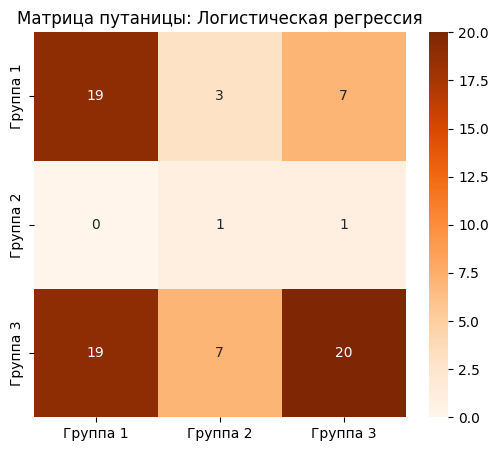


Дерево решений:
              precision    recall  f1-score   support

           1       0.48      0.48      0.48        29
           2       0.00      0.00      0.00         2
           3       0.68      0.70      0.69        46

    accuracy                           0.60        77
   macro avg       0.39      0.39      0.39        77
weighted avg       0.59      0.60      0.59        77



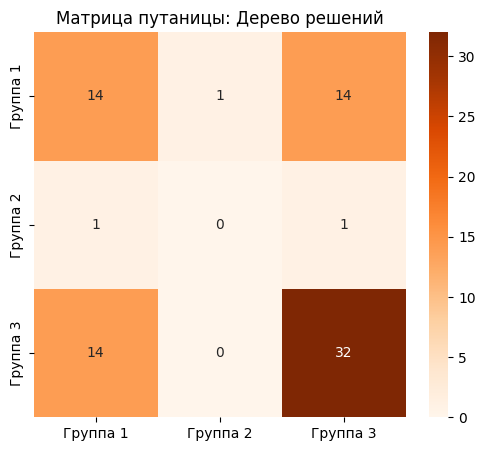


Случайный лес:
              precision    recall  f1-score   support

           1       0.67      0.48      0.56        29
           2       0.00      0.00      0.00         2
           3       0.71      0.87      0.78        46

    accuracy                           0.70        77
   macro avg       0.46      0.45      0.45        77
weighted avg       0.68      0.70      0.68        77



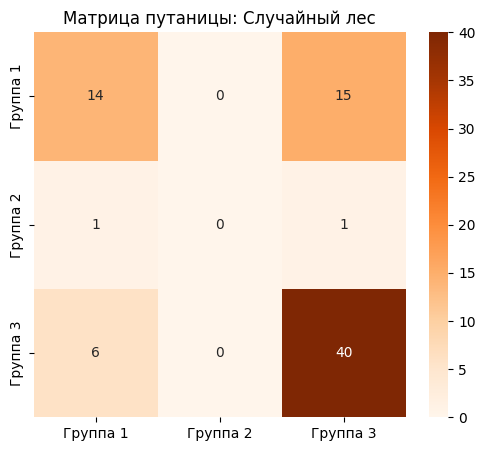


Градиентный бустинг:
              precision    recall  f1-score   support

           1       0.67      0.48      0.56        29
           2       0.00      0.00      0.00         2
           3       0.70      0.85      0.76        46

    accuracy                           0.69        77
   macro avg       0.45      0.44      0.44        77
weighted avg       0.67      0.69      0.67        77



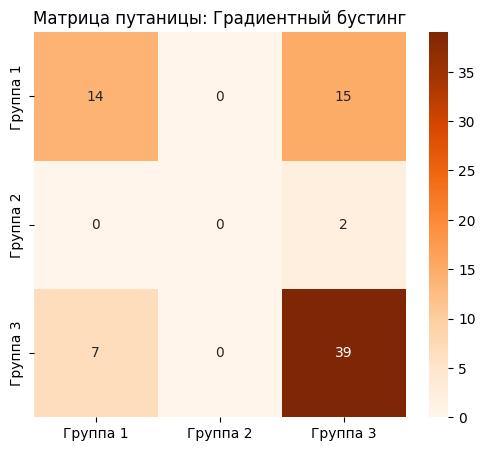


Сбалансированный случайный лес:
              precision    recall  f1-score   support

           1       0.57      0.69      0.62        29
           2       0.00      0.00      0.00         2
           3       0.81      0.54      0.65        46

    accuracy                           0.58        77
   macro avg       0.46      0.41      0.42        77
weighted avg       0.70      0.58      0.62        77



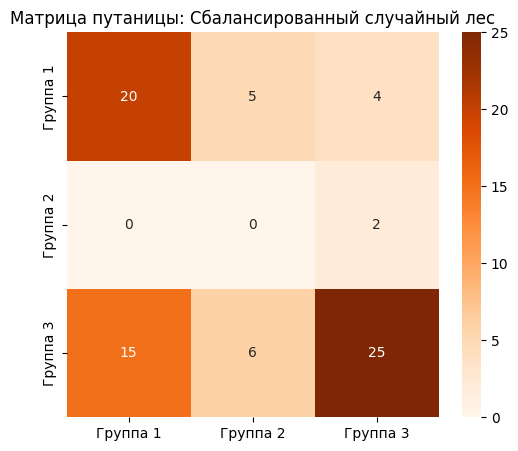


Бэггинг-классификатор:
              precision    recall  f1-score   support

           1       0.65      0.59      0.62        29
           2       0.00      0.00      0.00         2
           3       0.73      0.80      0.76        46

    accuracy                           0.70        77
   macro avg       0.46      0.46      0.46        77
weighted avg       0.68      0.70      0.69        77



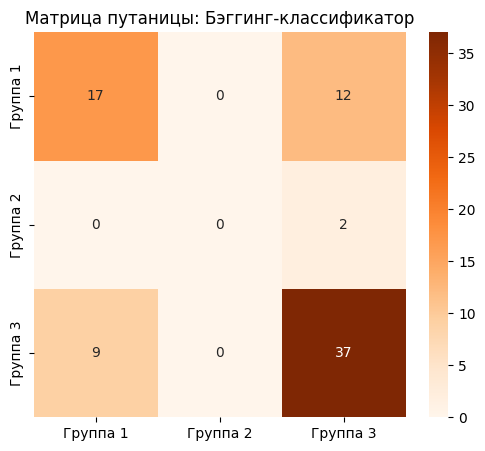


Кросс-валидация (F1 macro) — последний приоритет:
  Логистическая регрессия: 0.368 +/- 0.056
  Дерево решений: 0.510 +/- 0.164
  Случайный лес: 0.460 +/- 0.037
  Градиентный бустинг: 0.473 +/- 0.020
  Сбалансированный случайный лес: 0.438 +/- 0.032
  Бэггинг-классификатор: 0.449 +/- 0.037


In [6]:
df = pd.read_excel(file_name, sheet_name='Лист1', engine='openpyxl')

df['Приоритет_кафедры_низкий'] = df['Приоритет_кафедры_низкий'].replace(priority_mapping)
df['Группа'] = np.where(df['Приоритет_кафедры_низкий'].isin([1, 7]), 1,
                        np.where(df['Приоритет_кафедры_низкий'].isin([5]), 2, 3))

df['Информатика '] = df['Информатика '].fillna(0)
df['Физика'] = df['Физика'].fillna(0)
df = df.dropna(subset=['Математика', 'sr_o', 'Русский язык',
                       'индивидуальные_достижения балл', 'статус'])
df['направление_подготовки'] = df['направление_подготовки'].replace(direction_mapping)

X_low = df[['Русский язык', 'Математика', 'Информатика ', 'Физика', 'sr_o',
            'индивидуальные_достижения балл', 'направление_подготовки']]
y_low = df['Группа']

X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(
    X_low, y_low, test_size=0.2, random_state=42, stratify=y_low
)

scaler_low = StandardScaler()
X_train_low_sc = scaler_low.fit_transform(X_train_low)
X_test_low_sc  = scaler_low.transform(X_test_low)

for name, model in models.items():
    model.fit(X_train_low_sc, y_train_low)
    y_pred = model.predict(X_test_low_sc)
    print(f"\n{name}:")
    print(classification_report(y_test_low, y_pred, zero_division=0))

    cm = confusion_matrix(y_test_low, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Группа 1', 'Группа 2', 'Группа 3'],
                yticklabels=['Группа 1', 'Группа 2', 'Группа 3'])
    plt.title(f'Матрица путаницы: {name}')
    plt.show()

print("\nКросс-валидация (F1 macro) — последний приоритет:")
for name, model in models.items():
    pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    scores = cross_val_score(pipeline, X_low, y_low, cv=cv, scoring='f1_macro')
    print(f"  {name}: {scores.mean():.3f} +/- {scores.std():.3f}")



# Сравнение моделей, последний приоритет:



**Логистическая регрессия:**

Точность 52%, macro F1 0.42. Единственная модель, частично предсказавшая группу 2 (recall 0.50), однако precision катастрофически низкий (0.09), поэтому модель массово ошибочно относит объекты к этой группе.

Кросс-валидация: F1 macro = 0.368 ± 0.056 — наихудший результат.


**Дерево решений:**

Точность 60%, macro F1 0.39. Группа 2 не предсказана (precision и recall = 0).

Группы 1 и 3 предсказываются слабо.

 Кросс-валидация показала наибольший разброс: F1 macro = 0.510 ± 0.164 — модель нестабильна.



**Случайный лес:**

Точность 70%, macro F1 0.45. Группа 2 не предсказана. Группа 3 предсказывается хорошо (recall 0.87), группа 1 слабо (recall 0.48).

Кросс-валидация: F1 macro = 0.460 ± 0.037.



**Градиентный бустинг:**

Точность 69%, macro F1 0.44. Группа 2 не предсказана. Группа 3: recall 0.85, группа 1: recall 0.48.

Кросс-валидация: F1 macro = 0.473 ± 0.020 это наиболее стабильный результат среди всех моделей.


**Сбалансированный случайный лес:**

Точность 58%, macro F1 0.42. Группа 2 не предсказана. Группа 1 предсказывается лучше других моделей (recall 0.69), но за счёт снижения результатов по группе 3 (recall 0.54).

Кросс-валидация: F1 macro = 0.438 ± 0.032.


**Бэггинг-классификатор:**

Точность 70%, macro F1 0.46 и формально это лучший результат по тестовой выборке.

Группа 2 не предсказана. Кросс-валидация: F1 macro = 0.449 ± 0.037.


## **Итог**

**Лучшая модель по тестовой выборке:**

 Случайный лес и Бэггинг (accuracy 70%).


Наиболее стабильная по кросс-валидации:
Градиентный бустинг (F1 macro = 0.473 ± 0.020).

**Худшая модель:**

 Логистическая регрессия (кросс-валидация 0.368 ± 0.056).
Критическое ограничение: Ни одна модель не смогла предсказать группу 2, так как в тестовой выборке всего 2 объекта этого класса.

Результаты для последнего приоритета статистически недостоверны и не могут использоваться для практических выводов.

# **Анализ важности признаков**

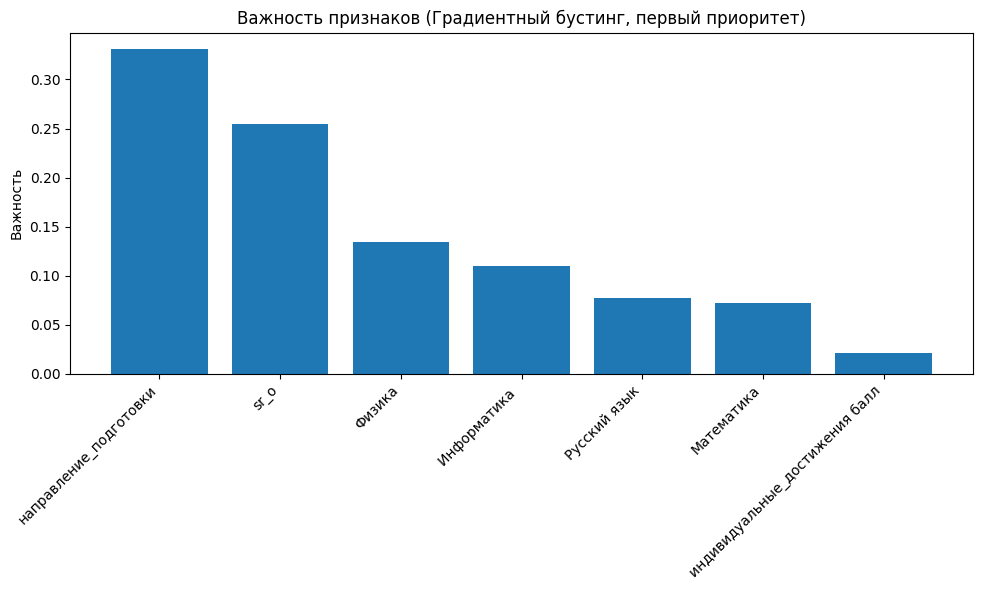

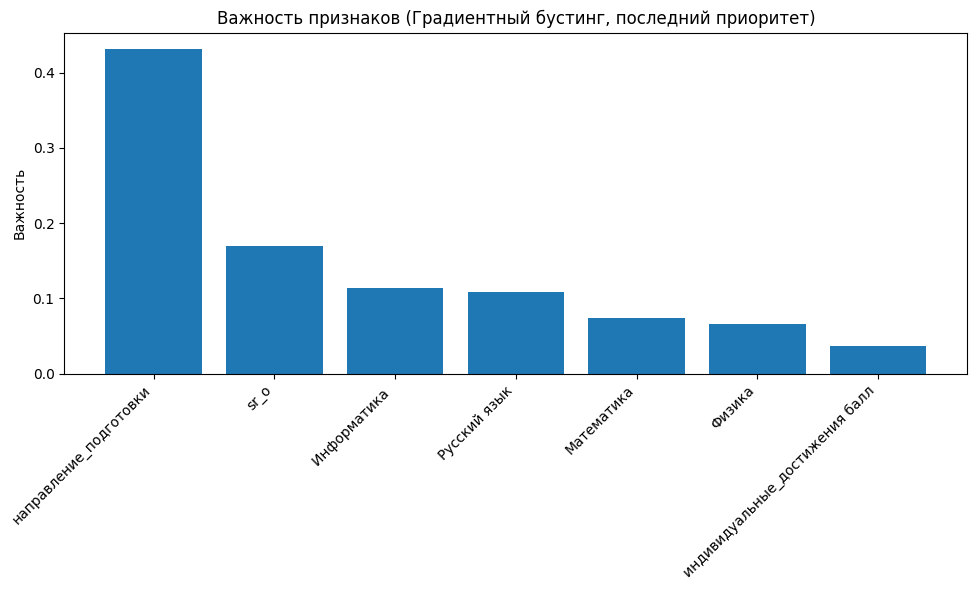


Важность признаков (Случайный лес, первый приоритет):
                       Признак  Важность
                          sr_o  0.241057
        направление_подготовки  0.222536
                  Русский язык  0.138054
                  Информатика   0.134367
                    Математика  0.127700
                        Физика  0.081391
индивидуальные_достижения балл  0.054895


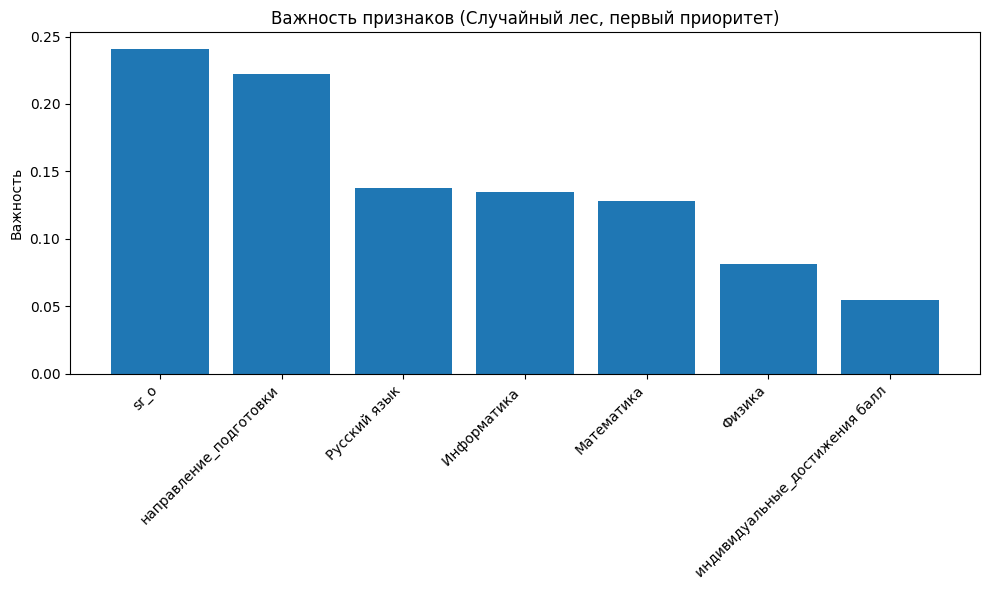


Важность признаков (Случайный лес, последний приоритет):
                       Признак  Важность
        направление_подготовки  0.249955
                          sr_o  0.190991
                  Русский язык  0.159749
                    Математика  0.127880
                  Информатика   0.122637
                        Физика  0.082180
индивидуальные_достижения балл  0.066608


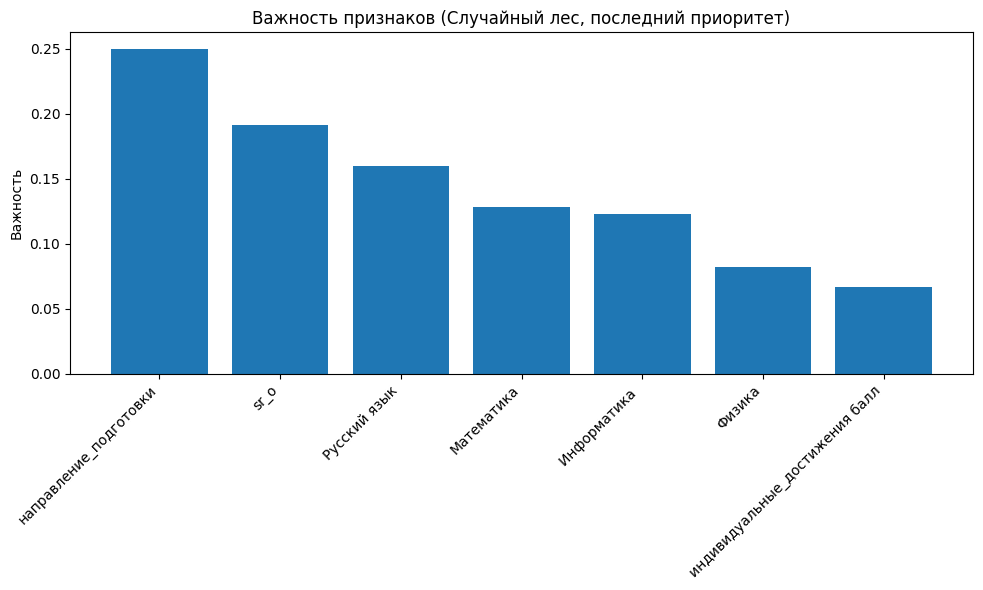

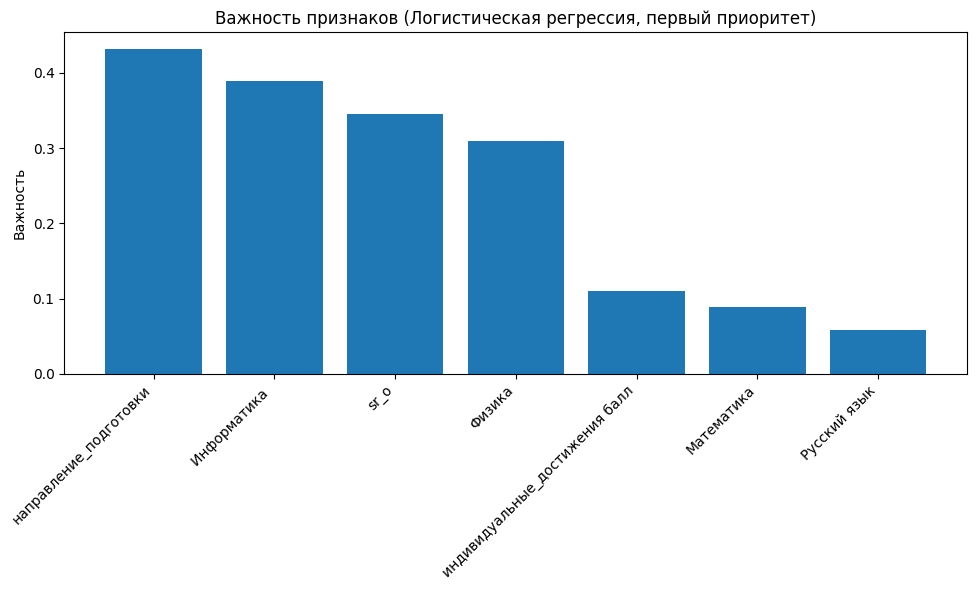

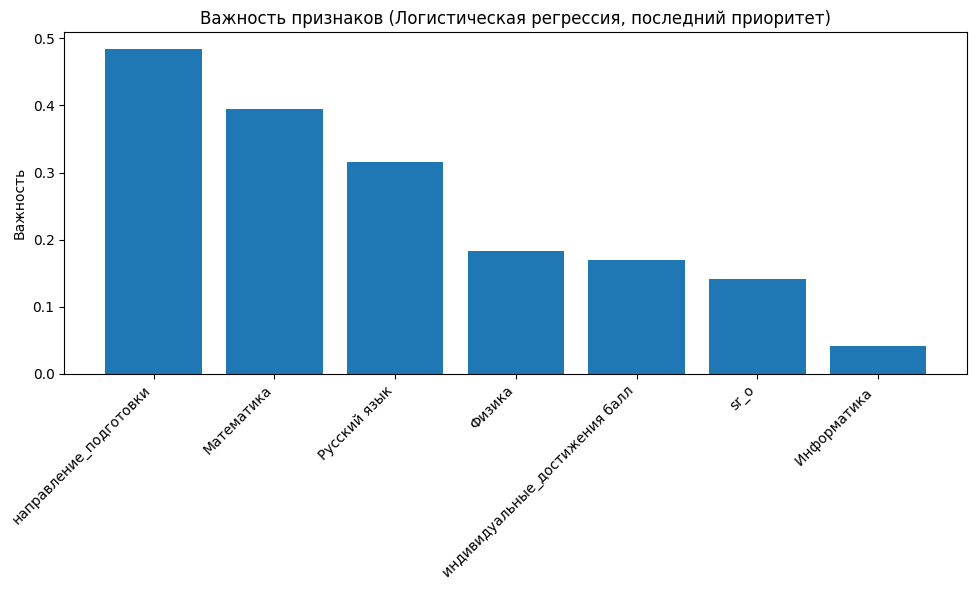

In [7]:

# Градиентный бустинг — первый приоритет
gb_high = GradientBoostingClassifier(random_state=42)
gb_high.fit(X_train_high_sc, y_train_high)
fi = gb_high.feature_importances_
idx = np.argsort(fi)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Градиентный бустинг, первый приоритет)")
plt.bar(range(X_high.shape[1]), fi[idx])
plt.xticks(range(X_high.shape[1]), X_high.columns[idx], rotation=45, ha='right')
plt.ylabel("Важность")
plt.tight_layout()
plt.show()

# Градиентный бустинг — последний приоритет
gb_low = GradientBoostingClassifier(random_state=42)
gb_low.fit(X_train_low_sc, y_train_low)
fi = gb_low.feature_importances_
idx = np.argsort(fi)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Градиентный бустинг, последний приоритет)")
plt.bar(range(X_low.shape[1]), fi[idx])
plt.xticks(range(X_low.shape[1]), X_low.columns[idx], rotation=45, ha='right')
plt.ylabel("Важность")
plt.tight_layout()
plt.show()

# Случайный лес — первый приоритет
rf_high = RandomForestClassifier(random_state=42)
rf_high.fit(X_train_high_sc, y_train_high)
fi = rf_high.feature_importances_
idx = np.argsort(fi)[::-1]
print("\nВажность признаков (Случайный лес, первый приоритет):")
print(pd.DataFrame({'Признак': X_high.columns[idx], 'Важность': fi[idx]}).to_string(index=False))
plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Случайный лес, первый приоритет)")
plt.bar(range(X_high.shape[1]), fi[idx])
plt.xticks(range(X_high.shape[1]), X_high.columns[idx], rotation=45, ha='right')
plt.ylabel("Важность")
plt.tight_layout()
plt.show()

# Случайный лес — последний приоритет
rf_low = RandomForestClassifier(random_state=42)
rf_low.fit(X_train_low_sc, y_train_low)
fi = rf_low.feature_importances_
idx = np.argsort(fi)[::-1]
print("\nВажность признаков (Случайный лес, последний приоритет):")
print(pd.DataFrame({'Признак': X_low.columns[idx], 'Важность': fi[idx]}).to_string(index=False))
plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Случайный лес, последний приоритет)")
plt.bar(range(X_low.shape[1]), fi[idx])
plt.xticks(range(X_low.shape[1]), X_low.columns[idx], rotation=45, ha='right')
plt.ylabel("Важность")
plt.tight_layout()
plt.show()

# Логистическая регрессия — первый приоритет
# coef_ имеет форму (n_classes, n_features), берём среднее по классам
lr_high = LogisticRegression(max_iter=1000, random_state=42)
lr_high.fit(X_train_high_sc, y_train_high)
fi = np.abs(lr_high.coef_).mean(axis=0)
idx = np.argsort(fi)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Логистическая регрессия, первый приоритет)")
plt.bar(range(X_high.shape[1]), fi[idx])
plt.xticks(range(X_high.shape[1]), X_high.columns[idx], rotation=45, ha='right')
plt.ylabel("Важность")
plt.tight_layout()
plt.show()

# Логистическая регрессия — последний приоритет
lr_low = LogisticRegression(max_iter=1000, random_state=42)
lr_low.fit(X_train_low_sc, y_train_low)
fi = np.abs(lr_low.coef_).mean(axis=0)
idx = np.argsort(fi)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Логистическая регрессия, последний приоритет)")
plt.bar(range(X_low.shape[1]), fi[idx])
plt.xticks(range(X_low.shape[1]), X_low.columns[idx], rotation=45, ha='right')
plt.ylabel("Важность")
plt.tight_layout()
plt.show()